In [1]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [4]:
from tqdm.notebook import tqdm
for i in tqdm(range(5)):
    pass


  0%|          | 0/5 [00:00<?, ?it/s]

In [5]:
df = pd.read_csv("../data/train_processed.csv", parse_dates=["Date"])
print(df.shape)
df.head()


(1017209, 28)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Year,Month,Day,WeekOfYear,DayOfYear,IsWeekend,Sales_lag_7,Sales_lag_30,Sales_roll_mean_7,Sales_roll_mean_30
0,1,2,2013-01-01,0,0,0,0,1,1,2,...,2013,1,1,1,1,0,0.0,0.0,0.0,0.0
1,1,3,2013-01-02,5530,668,1,0,0,1,2,...,2013,1,2,1,2,0,0.0,0.0,0.0,0.0
2,1,4,2013-01-03,4327,578,1,0,0,1,2,...,2013,1,3,1,3,0,0.0,0.0,0.0,0.0
3,1,5,2013-01-04,4486,619,1,0,0,1,2,...,2013,1,4,1,4,0,0.0,0.0,0.0,0.0
4,1,6,2013-01-05,4997,635,1,0,0,1,2,...,2013,1,5,1,5,1,0.0,0.0,0.0,0.0


In [6]:
store_id = 1
store_df = df[df["Store"] == store_id].copy()
store_df = store_df[store_df["Open"] == 1]   # ignore closed days


In [7]:
prophet_df = store_df.rename(columns={"Date": "ds", "Sales": "y"})
prophet_df = prophet_df[["ds", "y"]]
prophet_df.head()


,ds,y
1,2013-01-02,5530
2,2013-01-03,4327
3,2013-01-04,4486
4,2013-01-05,4997
6,2013-01-07,7176


In [8]:
train = prophet_df.iloc[:-42]
test = prophet_df.iloc[-42:]


In [9]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.5
)
model.fit(train)


14:33:20 - cmdstanpy - INFO - Chain [1] start processing
14:33:20 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(periods=42)
forecast = model.predict(future)


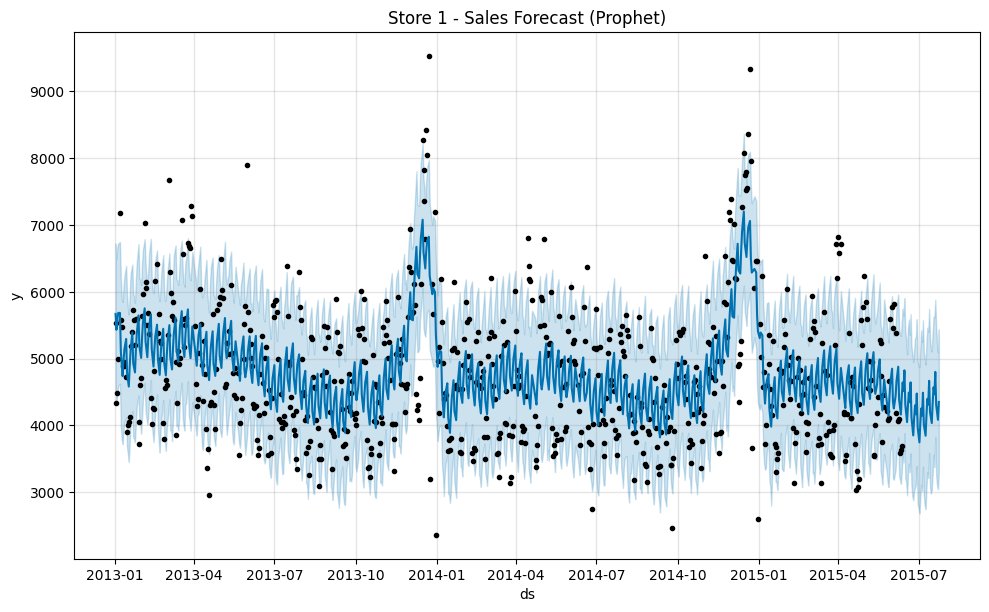

In [11]:
fig1 = model.plot(forecast)
plt.title(f"Store {store_id} - Sales Forecast (Prophet)")
plt.show()


In [12]:
pred = forecast.tail(42)["yhat"].values
true = test["y"].values

mae = mean_absolute_error(true, pred)
rmse = np.sqrt(mean_squared_error(true, pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 636.51
RMSE: 734.21


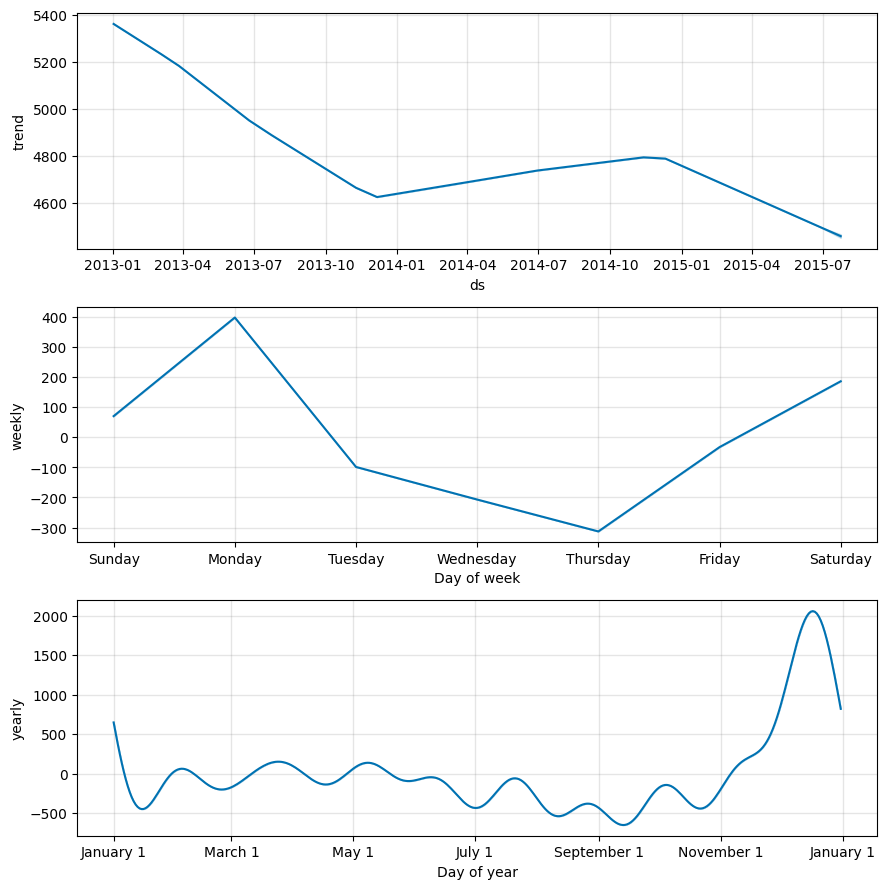

In [13]:
model.plot_components(forecast)
plt.show()
